# KK1 – PGA Tour-spelarstatistik

Analys av spelarsäsonger på PGA Tour 2015–2022. Vi utforskar tre frågor: vad kännetecknar de bästa spelarna, hur spelet har förändrats över tid, och om det finns en trade-off mellan drive-längd och precision.

## 1. Inledning

PGA Tour är den dominerande professionella herr-golftouren i Nordamerika. Spelarna åker runt på en säsong av turneringar, samlar prispengar och poäng. För varje spelare och säsong registrerar touren detaljerad statistik: hur långt de slår från tee, hur ofta de träffar fairwayn, hur många greens de når i regulation, hur de puttar och vilket scoring-snitt de spelar på.

**Källa:** Kaggle – https://www.kaggle.com/datasets/robikscube/pga-tour-golf-data-20152022

**En rad i datasetet** representerar en spelare en säsong – t.ex. "Rory McIlroy 2018". Det innebär att samma spelare kan finnas på flera rader (en per säsong de spelat).

**Population:** Aktiva tour-spelare 2015–2022 som hade tillräckligt med rundor för att kvalificera för officiell statistik. Datasetet säger alltså inget om amatörgolfare, kvinnliga touren (LPGA), seniortouren eller spelare som missat sin tour-card.

I notebooken utforskar vi tre frågor som tråd:

1. **Vad kännetecknar de bästa spelarna?** Vilka stats skiljer dem som vinner från resten?
2. **Hur har spelet förändrats över tid?** Slår de längre nu än 2015? Är scoringen lägre?
3. **Finns det en trade-off mellan drive-längd och precision?** Är de längsta också raka, eller är längd och precision oförenliga?

Vi läser in datan, inspekterar och tvättar den, och svarar sedan på frågorna med visualiseringar.

## 2. Inläsning och inspektion

Först en mekanisk översikt av datan – form, kolumner, datatyper och saknade värden – innan vi tvättar något.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Läs in datasetet (en rad per spelare per turnering, 2015–2022)
df = pd.read_csv("data/ASA All PGA Raw Data - Tourn Level.csv")
df.shape

(36864, 37)

In [2]:
df.head()

,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60
2,A. Lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,12.0,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54
3,A. Long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,12.0,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54
4,A. Noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,12.0,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36864 entries, 0 to 36863
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player_initial_last  36864 non-null  str    
 1   tournament id        36864 non-null  int64  
 2   player id            36864 non-null  int64  
 3   hole_par             36864 non-null  int64  
 4   strokes              36864 non-null  int64  
 5   hole_DKP             36864 non-null  float64
 6   hole_FDP             36864 non-null  float64
 7   hole_SDP             36864 non-null  int64  
 8   streak_DKP           36864 non-null  int64  
 9   streak_FDP           36864 non-null  float64
 10  streak_SDP           36864 non-null  int64  
 11  n_rounds             36864 non-null  int64  
 12  made_cut             36864 non-null  int64  
 13  pos                  21317 non-null  float64
 14  finish_DKP           36864 non-null  int64  
 15  finish_FDP           36864 non-null  int64  
 1

In [4]:
# Numerisk översikt av de kolumner som är relevanta för vår analys
df[["season", "n_rounds", "made_cut", "strokes",
    "sg_putt", "sg_arg", "sg_app", "sg_ott", "sg_t2g", "sg_total"]].describe()

,season,n_rounds,made_cut,strokes,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
count,36864.000000,36864.000000,36864.000000,36864.000000,29180.000000,29180.000000,29180.000000,29180.000000,29180.000000,29181.000000
mean,2018.539686,3.175266,0.605903,224.114502,-0.121005,-0.040744,-0.101759,-0.045896,-0.188346,-0.305491
std,2.213050,0.983446,0.488663,66.789007,1.119451,0.727315,1.119763,0.808139,1.640817,1.966669
min,2015.000000,1.000000,0.000000,66.000000,-5.990000,-6.430000,-9.250000,-7.740000,-13.950000,-13.670000
25%,2017.000000,2.000000,0.000000,146.000000,-0.770000,-0.450000,-0.740000,-0.450000,-1.080000,-1.370000
50%,2019.000000,4.000000,1.000000,272.000000,-0.040000,0.000000,0.000000,0.050000,-0.010000,-0.160000
75%,2021.000000,4.000000,1.000000,281.000000,0.630000,0.420000,0.640000,0.480000,0.920000,1.060000
max,2022.000000,4.000000,1.000000,325.000000,4.430000,3.170000,4.670000,2.770000,6.300000,8.520000


In [5]:
# Saknade värden per kolumn – vilka rader är ofullständiga och var?
df.isna().sum().sort_values(ascending=False).head(12)

Unnamed: 3             36864
Unnamed: 4             36864
Unnamed: 2             36864
pos                    15547
sg_t2g                  7684
sg_arg                  7684
sg_putt                 7684
sg_ott                  7684
sg_app                  7684
Finish                  7683
sg_total                7683
Player_initial_last        0
dtype: int64

**Observationer:**

- Datasetet har **36 864 rader** över **8 säsonger (2015–2022)** – varje rad är en spelares prestation i en specifik turnering.
- Spelaridentitet (`player`, `player_initial_last`), turnering (`tournament name`, `course`, `date`) och säsong (`season`) är kompletta.
- **Strokes Gained-kolumnerna** (`sg_putt`, `sg_app`, `sg_ott`, `sg_t2g`, `sg_total`) saknas i ~21 % av raderna (7 684 NaN). Dessa är hjärtat i vår analys, så vi behöver tänka igenom hur vi hanterar dem.
- Tre kolumner (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) är helt tomma – CSV-artefakter som tas bort i tvätten.
- Kolumnerna `hole_DKP`, `streak_FDP` etc. är fantasy-sport-scoring (DraftKings, FanDuel). Inte relevanta för vår analys, ignoreras.
- `pos` saknas för ~42 % av raderna – troligen för spelare som missade cut (deras position registreras inte numeriskt). `made_cut` (0/1) är en renare indikator.

## 3. Datatvätt

Inspektionen visade tre saker att åtgärda – inget mer, inget mindre:

1. **Tre tomma `Unnamed`-kolumner** är CSV-artefakter och tas bort.
2. **Strokes Gained saknas i ~21 % av raderna.** Eftersom hela vår analys hänger på SG-statistiken filtrerar vi bort raderna där den saknas, snarare än att gissa värden. Vi noterar dock att vi tappar 7 684 rader och reflekterar i avslutningen över vad det innebär för slutsatserna.
3. **Fantasy-scoring-kolumnerna (DKP/FDP/SDP)** ignorerar vi men låter ligga – de gör ingen skada och att aktivt rensa dem skulle bara vara kosmetik.

Vi parsar inga textintervall (som i hundatan) eftersom alla numeriska kolumner redan är `int64` eller `float64`.

In [6]:
# Steg 1: Släng de tre tomma Unnamed-kolumnerna
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.shape

(36864, 34)

In [7]:
# Steg 2: Filtrera bort rader där Strokes Gained saknas
# Vi använder sg_total som referens – övriga sg_*-kolumner saknas på exakt samma rader
fore = len(df)
df = df[df["sg_total"].notna()].reset_index(drop=True)
efter = len(df)
print(f"Rader före: {fore}, efter: {efter}, borttagna: {fore - efter}")

Rader före: 36864, efter: 29181, borttagna: 7683


In [8]:
# Verifiera: inga NaN kvar i sg-kolumnerna, rätt antal rader per säsong
print("NaN i sg-kolumner efter tvätt:")
print(df[["sg_putt", "sg_arg", "sg_app", "sg_ott", "sg_t2g", "sg_total"]].isna().sum().to_string())
print()
print("Rader per säsong efter tvätt:")
print(df["season"].value_counts().sort_index().to_string())

NaN i sg-kolumner efter tvätt:
sg_putt     1
sg_arg      1
sg_app      1
sg_ott      1
sg_t2g      1
sg_total    0

Rader per säsong efter tvätt:
season
2015    2699
2016    2958
2017    3604
2018    3968
2019    4377
2020    3704
2021    4762
2022    3109


**Resultat av tvätten:**

- Vi har kvar **29 181 rader** över alla 8 säsonger. Inga NaN kvar i sg-kolumnerna.
- Varje säsong är fortfarande välrepresenterad (mellan ~3 000 och ~4 700 rader per år), så jämförelser över tid är meningsfulla.
- Datan är nu redo att utforskas. Vi använder den både i sin tournament-form och – när frågan kräver det – aggregerar per spelare och säsong.

## 4. Visualiseringar

Här utforskar vi datan genom de tre frågorna vi formulerade i inledningen, plus en extra cell där vi prövar två diagramtyper för samma fråga.

### Fråga 1 – Vad kännetecknar de bästa spelarna?

För att svara behöver vi först definiera "bäst". Datan är på turneringsnivå, så vi aggregerar till **spelar-säsong**: hur många turneringar deltog spelaren i, hur många cuts klarade hen, och vad var medelvärdet för varje Strokes Gained-komponent över säsongen?

Sedan delar vi spelar-säsongerna i två grupper baserat på **cut-rate** (andel cuts klarade): topp-kvartilen (≥73 %) är "topp", resten är "övriga". Vi filtrerar bort säsonger med färre än 5 turneringar för att cut-rate ska vara meningsfull.

In [9]:
# Aggregera till spelar-säsong-nivå
sg_kolumner = ["sg_putt", "sg_arg", "sg_app", "sg_ott", "sg_t2g", "sg_total"]
spelare_sasong = (
    df.groupby(["player", "season"])
      .agg(events=("made_cut", "size"),
           cuts=("made_cut", "sum"),
           **{kol: (kol, "mean") for kol in sg_kolumner})
      .reset_index()
)
spelare_sasong["cut_rate"] = spelare_sasong["cuts"] / spelare_sasong["events"]

# Filtrera till säsonger med >= 5 turneringar (stabil cut-rate)
spelare_sasong = spelare_sasong[spelare_sasong["events"] >= 5].reset_index(drop=True)
print(f"Spelar-säsonger efter filter: {len(spelare_sasong)}")
spelare_sasong.head()

Spelar-säsonger efter filter: 1777


,player,season,events,cuts,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total,cut_rate
0,Aaron Baddeley,2015,15,8,0.346000,0.314000,-0.945333,-0.550667,-1.180667,-0.834667,0.533333
1,Aaron Baddeley,2016,17,10,0.407647,0.425294,-0.460000,-0.584118,-0.617647,-0.210588,0.588235
2,Aaron Baddeley,2017,14,5,0.156429,0.270000,0.319286,-0.849286,-0.259286,-0.103571,0.357143
3,Aaron Baddeley,2018,22,12,-0.138182,0.601364,-0.001364,-0.472273,0.128182,-0.008182,0.545455
4,Aaron Baddeley,2019,15,9,0.546000,0.347333,-0.408667,-0.454000,-0.515333,0.031333,0.600000


In [10]:
# Definiera topp-grupp = topp-kvartilen efter cut-rate
topp_grans = spelare_sasong["cut_rate"].quantile(0.75)
spelare_sasong["grupp"] = np.where(spelare_sasong["cut_rate"] >= topp_grans, "Topp", "Övriga")

# Fyra kvartilgrupper för gradvis jämförelse
spelare_sasong["kvartil"] = pd.qcut(
    spelare_sasong["cut_rate"], q=4,
    labels=["Kv. 1\n(svagast)", "Kv. 2", "Kv. 3", "Kv. 4\n(starkast)"],
    duplicates="drop"
)

print(f"Cut-rate-tröskel för topp-grupp: {topp_grans:.2%}")
print("\nGruppstorlekar (Topp/Övriga):")
print(spelare_sasong["grupp"].value_counts().to_string())
print("\nKvartilfördelning:")
print(spelare_sasong["kvartil"].value_counts().sort_index().to_string())

Cut-rate-tröskel för topp-grupp: 73.33%

Gruppstorlekar (Topp/Övriga):


grupp
Övriga    1328
Topp       449

Kvartilfördelning:
kvartil
Kv. 1\n(svagast)     449
Kv. 2                453
Kv. 3                436
Kv. 4\n(starkast)    439


C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\4120920886.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=etiketter)
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\4120920886.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=etiketter)
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\4120920886.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=etiketter)
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\4120920886.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplot

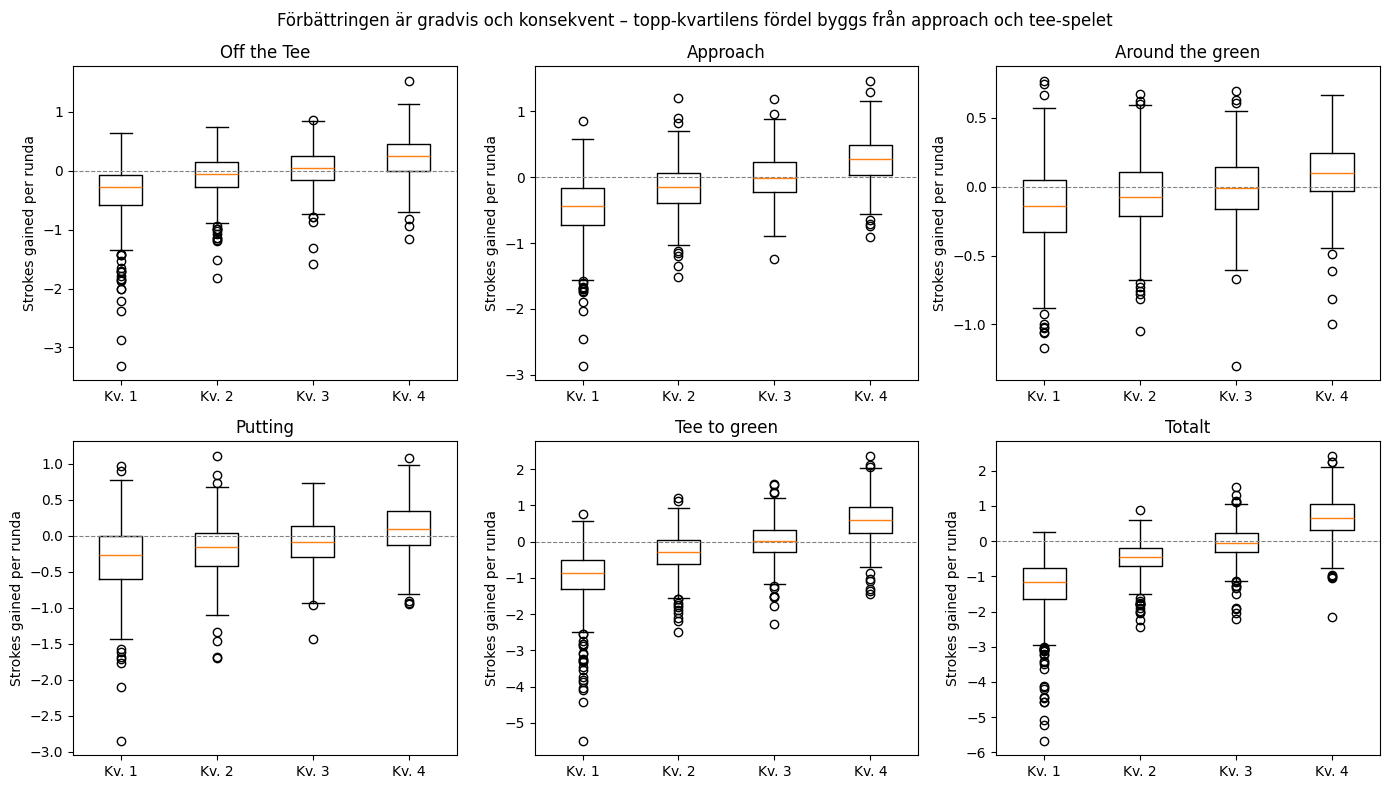

In [11]:
# Detaljerad boxplot: 4 kvartilgrupper × 6 SG-komponenter
# Visar gradienten från svagast till starkast
komponenter = [
    ("sg_ott",   "Off the Tee"),
    ("sg_app",   "Approach"),
    ("sg_arg",   "Around the green"),
    ("sg_putt",  "Putting"),
    ("sg_t2g",   "Tee to green"),
    ("sg_total", "Totalt"),
]
kvartiler = ["Kv. 1\n(svagast)", "Kv. 2", "Kv. 3", "Kv. 4\n(starkast)"]
etiketter  = ["Kv. 1", "Kv. 2", "Kv. 3", "Kv. 4"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
for ax, (kol, namn) in zip(axes.flat, komponenter):
    data = [spelare_sasong.loc[spelare_sasong["kvartil"] == g, kol] for g in kvartiler]
    ax.boxplot(data, labels=etiketter)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(namn)
    ax.set_ylabel("Strokes gained per runda")

fig.suptitle(
    "Förbättringen är gradvis och konsekvent – topp-kvartilens fördel byggs från approach och tee-spelet",
    fontsize=12)
fig.tight_layout()
plt.show()

C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\3973619159.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Övriga", "Topp"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\3973619159.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Övriga", "Topp"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\3973619159.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Övriga", "Topp"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\3973619159.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tic

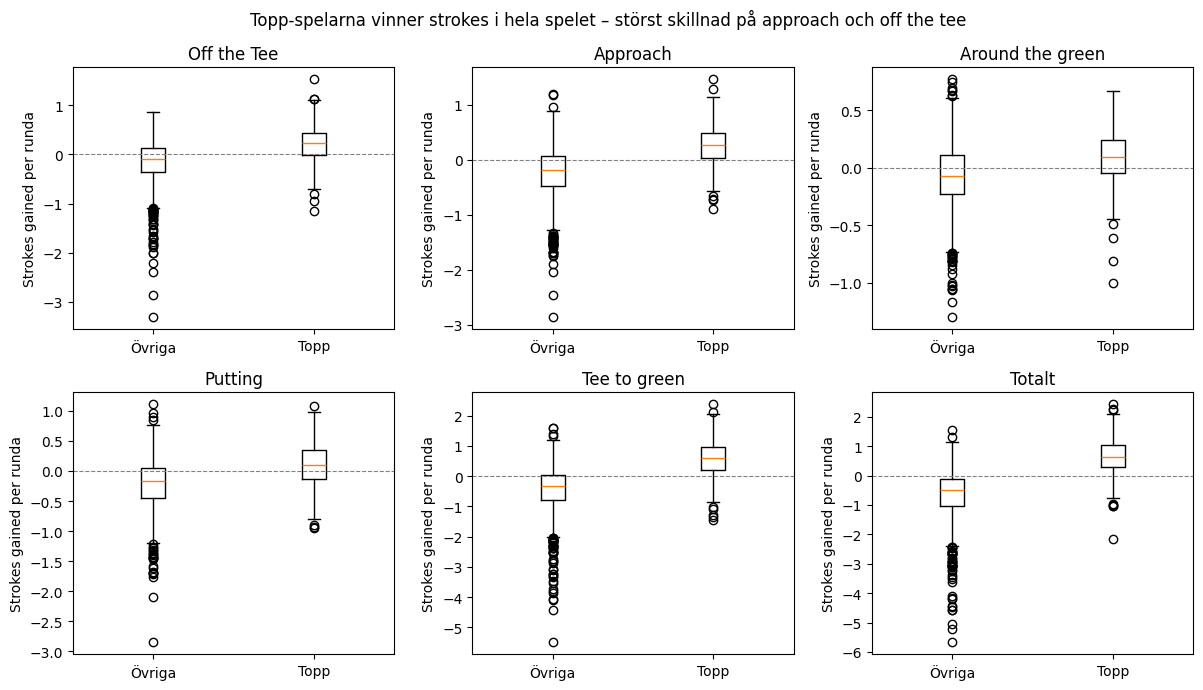

In [12]:
# Enkel sammanfattning: Topp vs Övriga för alla sex komponenter
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=False)
for ax, (kol, namn) in zip(axes.flat, komponenter):
    data = [spelare_sasong.loc[spelare_sasong["grupp"] == g, kol]
            for g in ["Övriga", "Topp"]]
    ax.boxplot(data, labels=["Övriga", "Topp"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(namn)
    ax.set_ylabel("Strokes gained per runda")

fig.suptitle("Topp-spelarna vinner strokes i hela spelet – störst skillnad på approach och off the tee",
             fontsize=12)
fig.tight_layout()
plt.show()

Kvartil-diagrammet visar att förbättringen är **gradvis och linjär** – varje steg uppåt i cut-rate ger ett steg uppåt i SG-medianen för i princip alla komponenter. Topp-kvartilen (Kv. 4) skiljer sig från alla övriga, inte bara den näst bästa.

Den enkla Topp/Övriga-jämförelsen bekräftar och förenklar bilden: skillnaden är störst i **approach** (sg_app) och **off the tee** (sg_ott) – topp-spelarnas medianer ligger klart över noll medan övrigas ligger under. **Putting** (sg_putt) skiljer sig också, men spridningen är bred i båda grupperna: bra puttning är en variabel även bland topp-spelare. **Around the green** (sg_arg) är den minsta skillnaden – kortspelet runt greenen är inte där eliten gör sin största vinst.

### Fråga 2 – Hur har spelet förändrats över tid?

Strokes Gained är mätt mot fältet vilket gör att medelvärdet alltid är ~0 per säsong – det är inte rätt mått för att se förändring över tid. Istället tittar vi på **strokes per runda** för spelare som klarat cut. Det är en mer direkt mätare av hur lågt det går att spela på tourens banor under en given säsong.

Vi visar medelvärdet per säsong med ett band för IQR (25:e–75:e percentilen) för att kombinera centraltendens med spridning.

In [13]:
# Aggregera strokes per runda per säsong (endast made-cut-spelare)
df["strokes_per_runda"] = df["strokes"] / df["n_rounds"]
made_cut = df[df["made_cut"] == 1]

per_sasong = made_cut.groupby("season")["strokes_per_runda"].agg(
    medel="mean",
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75),
).round(2)
per_sasong

,medel,q25,q75
season,,,
2015,70.12,69.00,71.25
2016,70.22,68.75,71.50
2017,70.26,69.00,71.50
2018,69.89,68.75,71.00
2019,69.35,68.50,71.00
2020,69.93,68.50,71.25
2021,69.97,68.50,71.25
2022,70.06,68.75,71.25


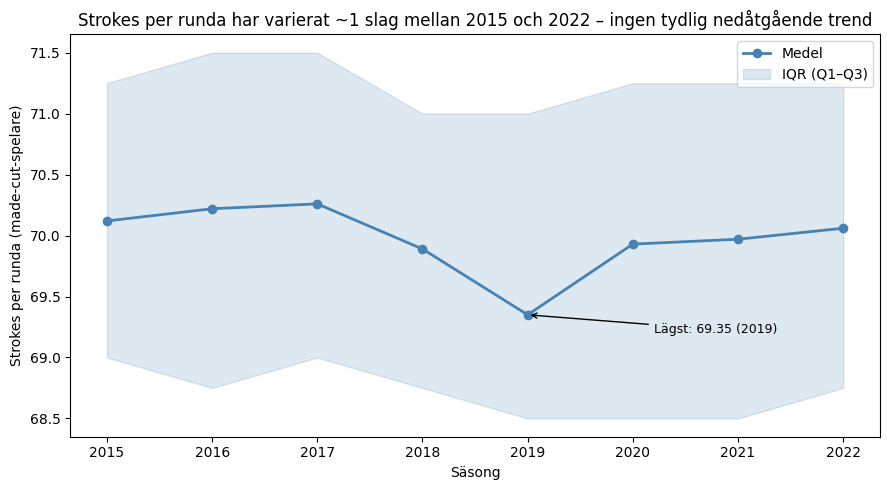

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(per_sasong.index, per_sasong["medel"], marker="o", color="steelblue",
        linewidth=2, label="Medel")
ax.fill_between(per_sasong.index, per_sasong["q25"], per_sasong["q75"],
                color="steelblue", alpha=0.18, label="IQR (Q1–Q3)")

# Annotera lägsta året
lagsta_ar = per_sasong["medel"].idxmin()
lagsta_v = per_sasong["medel"].min()
ax.annotate(f"Lägst: {lagsta_v:.2f} ({lagsta_ar})",
            xy=(lagsta_ar, lagsta_v),
            xytext=(lagsta_ar + 1.2, lagsta_v - 0.15),
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            fontsize=9)

ax.set_title("Strokes per runda har varierat ~1 slag mellan 2015 och 2022 – ingen tydlig nedåtgående trend",
             fontsize=12)
ax.set_xlabel("Säsong")
ax.set_ylabel("Strokes per runda (made-cut-spelare)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

Spelet har inte blivit konsekvent lättare under åren. Det fanns en svacka 2018–2019 där medelscoren låg ungefär ett halvt slag lägre per runda, men 2020 och framåt återgår scoren till nivåer som liknar 2015. IQR-bandet är ungefär lika brett varje år (~2 slag mellan Q1 och Q3) – spridningen mellan bra och sämre dagar har inte ändrats.

Ett viktigt förbehåll: PGA Tours kalender ändras år för år. Vilka banor som spelas påverkar scoring direkt – en svår banrotation ett år kan höja medelscoren oavsett spelarnas faktiska form. Vi kan inte separera "spelarna spelar bättre" från "banorna är lättare" med den här datan.

### Fråga 3 – Finns det en trade-off mellan tee-spel och putting?

En vanlig föreställning är att spelare antingen är starka från tee *eller* bra puttare – att de "kompenserar". Vi undersöker om det finns ett negativt samband mellan **sg_ott** (tee-spelet) och **sg_putt** (putting) på spelar-säsong-nivå.

Scatter-diagrammet lämpar sig här: det visar hur de två komponenterna förhåller sig till varandra för varje spelare-säsong, och kvadrantlinjer vid noll gör det enkelt att se i vilken riktning sambandet lutar.

In [ ]:
grupp_stil = {
    "Övriga": {"color": "coral",     "alpha": 0.56, "s": 30},
    "Topp":   {"color": "steelblue", "alpha": 0.70, "s": 30},
}

fig, ax = plt.subplots(figsize=(8, 6))

for grupp, stil in grupp_stil.items():
    mask = spelare_sasong["grupp"] == grupp
    ax.scatter(spelare_sasong.loc[mask, "sg_ott"],
               spelare_sasong.loc[mask, "sg_putt"],
               c=stil["color"], label=grupp,
               alpha=stil["alpha"], s=stil["s"], linewidths=0)

# Kvadrantlinjer
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

# Annotera topp-klustret i positiv sg_ott-region
ax.annotate("Topp-spelarna dominerar\nhöger halva (starkt tee-spel)\noavsett putting-nivå",
            xy=(0.35, 0.05), xytext=(0.65, -0.45),
            arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
            fontsize=8.5, ha="center")

ax.set_xlabel("Strokes Gained: Off the Tee")
ax.set_ylabel("Strokes Gained: Putting")
ax.set_title("Inget trade-off – tee-spelet skiljer vinnarna, inte om de kompenserar med putting",
             fontsize=11)
ax.legend(title="Grupp")
fig.tight_layout()
plt.show()

Punktmolnet är brett och utan tydlig lutning – inget starkt linjärt samband i någon riktning. Topp-spelarna (blå) klustrar åt höger (positiv sg_ott) men spretar i alla riktningar längs y-axeln. Det bekräftar bilden från fråga 1: tee-spelet är den tydligaste separatorn, inte putting.

En viktig begränsning: vi mäter *relativa* SG-värden jämfört med fältet per turnering. Att sg_ott och sg_putt är oberoende här utesluter inte att bägge förbättras hos spelare som tränar mer – vi ser bara att de inte kompenserar varandra inom tourens normalspridning.

### Diagramvalsförsök – fråga 3

För frågan om trade-off finns två rimliga diagramtyper: **scatter** (visar sambandet mellan de två variablerna direkt) och **boxplot** (visar fördelningarna per grupp separat). Jag testade båda; nedan syns boxplot-alternativet.

C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\389838234.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Övriga", "Topp"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_37604\389838234.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Övriga", "Topp"])


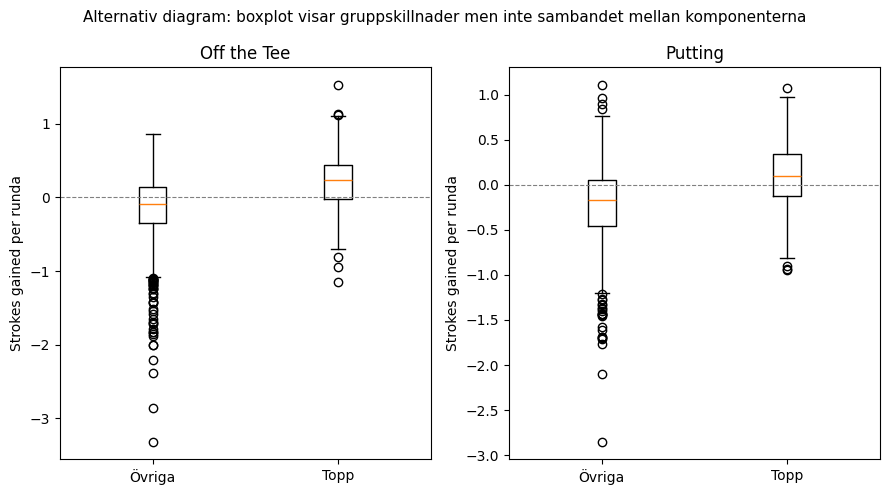

In [16]:
# Alternativ: side-by-side boxplot för sg_ott och sg_putt per grupp
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=False)

for ax, (kol, namn) in zip(axes, [("sg_ott", "Off the Tee"), ("sg_putt", "Putting")]):
    data = [spelare_sasong.loc[spelare_sasong["grupp"] == g, kol]
            for g in ["Övriga", "Topp"]]
    ax.boxplot(data, labels=["Övriga", "Topp"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(namn)
    ax.set_ylabel("Strokes gained per runda")

fig.suptitle("Alternativ diagram: boxplot visar gruppskillnader men inte sambandet mellan komponenterna",
             fontsize=11)
fig.tight_layout()
plt.show()

**Boxplotten visar tydligt att topp-spelarna är bättre *i genomsnitt* på båda komponenterna, men den kan inte svara på om de är bra *på samma gång* – det vill säga, om den spelare som den veckan slog långt också puttade bättre. Det behöver ett spridningsdiagram för att visa.**

Jag testade alltså båda: boxplot ger grupp-jämförelse, scatter visar relationen. Eftersom frågan handlar om *samband* (trade-off eller ej) är scatter rätt val – boxplotten svarar på en annan fråga.

## 5. Avslutning

### Vad vi lärde oss

**Fråga 1 – Vad kännetecknar de bästa spelarna?**
Topp-spelarna (topp-kvartilen mätt i cut-rate) vinner strokes i *alla* delar av spelet – men skillnaden mot resten är störst i **approach** (sg_app) och **off the tee** (sg_ott). Det långa spelet separerar eliten mer än putting gör. Putting-spridningen är bred i båda grupperna: det går att vara med i topp med medelbra putting om man är exceptionell från tee och approach.

**Fråga 2 – Hur har spelet förändrats över tid?**
Ingen tydlig nedåtgående trend i scoring syns under 2015–2022. Det fanns en temporär svacka 2018–2019, men scoren återgick till 2015-nivåer från 2020 och framåt. IQR-bandet (spridningen mellan Q1 och Q3) är ungefär lika brett varje år – spelet verkar varken ha blivit lättare eller svårare som helhet.

**Fråga 3 – Finns det en trade-off mellan tee-spel och putting?**
Inget tydligt negativt samband. Scatter-diagrammet visar ett brett, ungefär cirkulärt punktmoln – sg_ott och sg_putt är i stort sett oberoende. Topp-spelarna dominerar den positiva sg_ott-halvan men spretar i alla riktningar längs putting-axeln. Teorin att "långa slagare pruttar på puttingen" stöds inte av datan.

---

### Vad datan inte kan berätta

**Urval och kalender.** Datasetet täcker bara spelare med tillräckligt många rundor för officiell statistik – lågrankat spel och kvalspel saknas. Banrotationen varierar år för år, vilket direkt påverkar scoring-nivån utan att spegla att spelarna blivit bättre eller sämre.

**Kausalitet.** Att topp-spelare har högre sg_app säger inget om *varför* – det kan vara träningsvolym, utrustning, caddie-val eller rena naturliga förutsättningar. SG mäter utfall, inte process.

**Utanför populationen.** Slutsatserna gäller PGA Tour-herrar 2015–2022. De är inte generaliserbara till LPGA, Korn Ferry Tour, amatörgolf eller äldre epoker.